# Introduction

now for report_pipeline.py

1. We'll run the inference and get the plots for all individual models and overall report
2. finally We create a report table df1 with these columns:
    * Ground Truth (this will be taken from spnwer)
    * Does it have airborne_status (Ground_truth)
    * Does it have remote_override_flag (ground_truth)
    * SL_answer
    * SL_conf
    * Does_match with ground_truth with more than 98% conf (if yes, level 1 cleared)
         - ex - If SL AGV (fly or no fly) matches with ground_truth AGV and level 1 check complete
    * Does it mathces override_flag or airborne_status (as Sl will divide into 7 classfication, so we'll know if it is flaged with these) (if yes level 2 is cleared)
        - ex - if SL AGV (fly) means Airbone_status(from ground truth) should be true, if not level 2 fails. same for robotic_arm in overide case.
    * USL_answer
    * USL_conf
    * Does_match with ground_truth with more than 95% conf (if yes, level 3 cleared)
    * Level_cleared (1 or 2 or 3)
3. Another table df2 where I run multiple runs with different combinations of models (We'll be specfy which model we are choosing for SL, usl, RL, at start of every run)
    * USL_model
    * SL_model
    * RL_model
    * Points_level_cleared (if all 3 level is cleared than 3 points, if only 2 level are cleared than only 2 points and same for 1, so max point is 30, 3x10 10, locations)
    * Total rewards collected by RL
    * Time taken by RL model to complete (this will be)
4. We have to see (visualize) the arrow navigating rl env.
5. Rows will be 10 locations which is set by spanwer for df1, it also collect 100 rows and 100 images


# Training

SUPERVISED LEARNING MODELS TRAINING......

Training Random Forest........
Random Forest trained successfully in 0.04801 seconds.

Training SVM........
SVM trained successfully in 1.70023 seconds.
SUPERVISED LEARNING MODELS TRAINING COMPLETE

UNSUPERVISED LEARNING MODELS TRAINING......

Starting CAE Training...
Locking down randomness with seed: 47
Dataset Split → 6414 training images / 1604 validation images
Epoch [1/20] | Train Loss: 0.057349 | Val Loss: 0.016747
Epoch [2/20] | Train Loss: 0.014723 | Val Loss: 0.013011
Epoch [3/20] | Train Loss: 0.011699 | Val Loss: 0.011284
Epoch [4/20] | Train Loss: 0.010533 | Val Loss: 0.010190
Epoch [5/20] | Train Loss: 0.009366 | Val Loss: 0.009123
Epoch [6/20] | Train Loss: 0.008443 | Val Loss: 0.008298
Epoch [7/20] | Train Loss: 0.007758 | Val Loss: 0.007823
Epoch [8/20] | Train Loss: 0.007308 | Val Loss: 0.007345
Epoch [9/20] | Train Loss: 0.006896 | Val Loss: 0.007057
Epoch [10/20] | Train Loss: 0.006562 | Val Loss: 0.006758
Epoch [11/20] | T

CV Features: 100%|██████████| 8018/8018 [00:11<00:00, 685.66it/s]


Training Data Saved! Final tensor shape: (8018, 16)

Training USL Model - GMM...
Features loaded successfully. Shape: (8018, 16)
Fitting GMM with 5 components...
GMM converged in 13 iterations.
GMM model saved to: MODELS/gmm_model.pkl
GMM Training finished in 20.85923s

Training USL Model - DEC...
Locking down randomness with seed: 47
Running BIRCH to generate pseudo-labels for warm-up phase...
Training DEC: 15 Epochs CE Warm-Up -> 65 Epochs
Epoch [10/80] | Warm-Up | Train Loss: 0.0314 | Val Loss: 0.0452
Epoch [20/80] | Self-Supervised | Train Loss: 0.0076 | Val Loss: 0.0079
Epoch [30/80] | Self-Supervised | Train Loss: 0.0038 | Val Loss: 0.0047
Epoch [40/80] | Self-Supervised | Train Loss: 0.0027 | Val Loss: 0.0033
Epoch [50/80] | Self-Supervised | Train Loss: 0.0022 | Val Loss: 0.0028
Epoch [60/80] | Self-Supervised | Train Loss: 0.0016 | Val Loss: 0.0027
Epoch [70/80] | Self-Supervised | Train Loss: 0.0014 | Val Loss: 0.0025
Epoch [80/80] | Self-Supervised | Train Loss: 0.0009 | Val

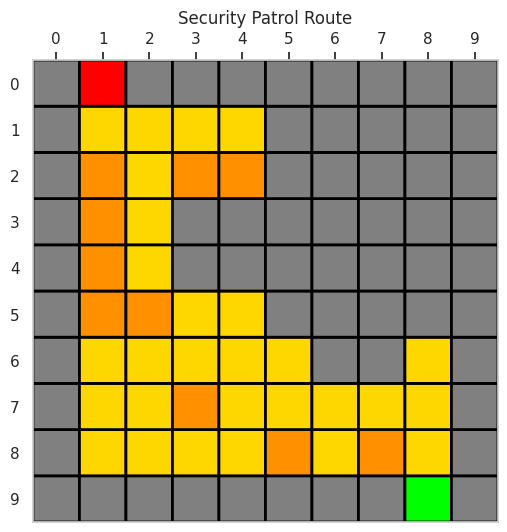

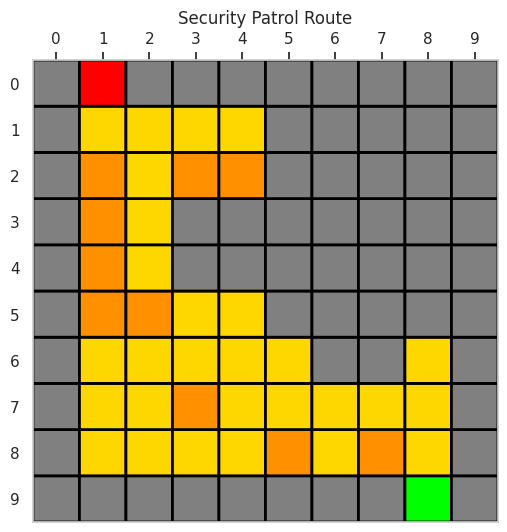

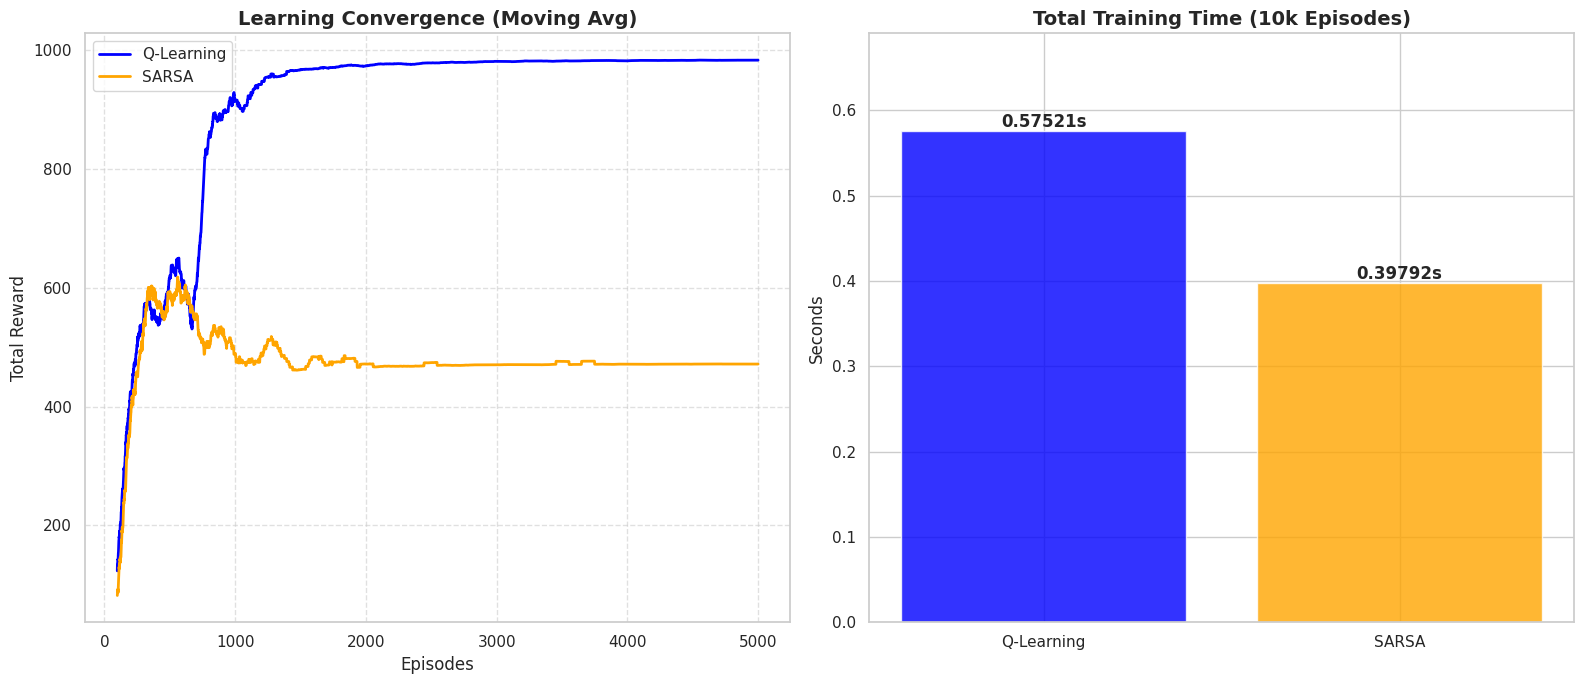

In [ ]:
"""
File: train_all.py
This script serves as the master execution hub for the entire project, orchestrating
the training pipelines for Supervised Learning (SL), Unsupervised Learning (USL),
and Reinforcement Learning (RL) sequentially.


from pathlib import Path
from mapping import map_csv, map_imgs
from SL_training.train_sl_models import SLTraining
from USL_training.train_usl_models import USLTraining
from RL_training.train_rl_models import RLTraining


if __name__ == "__main__":

    # CREATING FOLDERS
    IMG_PATH = "DATA/DATASET"
    CSV_PATH = "DATA/SENSOR_STATS.csv"
    PLOT_PATH = "PLOTS/"
    MODEL_PATH = "MODELS/"
    SEED = 47
    if not Path(CSV_PATH).exists(): map_csv()
    if not Path(IMG_PATH).exists(): map_imgs()
    Path(PLOT_PATH).mkdir(parents=True, exist_ok=True) # For All Plots
    Path(MODEL_PATH).mkdir(parents=True, exist_ok=True) # For All Models

    # SUPERVISED LEARNING PIPELINE
    print("SUPERVISED LEARNING MODELS TRAINING......")
    sl_trainer = SLTraining(seed=SEED, data_path=CSV_PATH, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
    sl_trainer.train_sl_models()
    print("SUPERVISED LEARNING MODELS TRAINING COMPLETE\n")

    # UNSUPERVISED LEARNING PIPELINE
    print("UNSUPERVISED LEARNING MODELS TRAINING......")
    usl_trainer = USLTraining(seed=SEED, data_dir=IMG_PATH, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
    usl_trainer.train_usl_models()
    print("UNSUPERVISED LEARNING MODELS TRAINING COMPLETE\n")

    # REINFORCEMENT LEARNING PIPELINE
    print("REINFORCEMENT LEARNING MODELS TRAINING......")
    rl_trainer = RLTraining(episodes=5000, seed=SEED, plot_dir = PLOT_PATH, model_dir = MODEL_PATH)
    rl_trainer.train_rl_models()
    print("REINFORCEMENT LEARNING MODELS TRAINING COMPLETE")
"""


# Inference

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
from collections import Counter

from RL_env.spanwer import DataSpawner
from RL_env.env_gen import MapGenerator
from SL_training.sl_inference import SLInference
from USL_training.usl_inference import USLInference
from RL_training.rl_inference import RLInference

SL_MODELS  = ["rf_model.pkl",    "svm_model.pkl"]
USL_MODELS = [("gmm", "gmm_model.pkl"), ("dec", "dec_model.pt")]
RL_MODELS  = ["q_brain.json",    "sarsa_brain.json"]

def parse_label(label):
    if label.startswith("robotic_arm"):
        return "robotic_arm", label[12:]
    elif label.startswith("agv_unit"):
        return "agv_unit", label[9:]
    else:
        parts = label.split("_")
        return parts[0], "_".join(parts[1:])

def evaluate_levels(gt, air, override, sl_ans, sl_conf, usl_ans, usl_conf):
    gt_base, _          = parse_label(gt)
    sl_base, sl_attrs   = parse_label(sl_ans)
    l1 = (sl_base == gt_base) and (sl_conf > 0.98)
    fly_ok      = ("fly" in sl_attrs) if air else ("non_fly" in sl_attrs or "fly" not in sl_attrs)
    override_ok = ("override" in sl_attrs) if override else ("non_override" in sl_attrs or "override" not in sl_attrs)
    l2 = fly_ok and override_ok
    l3 = (usl_ans == gt) and (usl_conf > 0.95)
    return l1, l2, l3, int(l1) + int(l2) + int(l3)

def aggregate_usl_result(result, class_names):
    majority_cluster = Counter(result.predictions).most_common(1)[0][0]
    majority_mask    = result.predictions == majority_cluster
    return class_names[majority_cluster], float(np.mean(result.confidences[majority_mask]))

def combo_tag(sl_file, usl_name, rl_file):
    sl = sl_file.replace(".pkl", "").replace(".pt", "")
    rl = rl_file.replace(".json", "")
    return f"{sl}__{usl_name}__{rl}"

In [ ]:
'''
Path("RESULTS").mkdir(exist_ok=True)
print("[1] Initializing Data Spawner and Environments...")
spawner = DataSpawner(csv_path="DATA/SENSOR_STATS.csv", image_dir="DATA/DATASET")
map_gen = MapGenerator(seed=47)
map_gen.generate_map()

# Consolidated containers
all_df1_rows = []
df2_rows = []

total_pipeline_time = 0.0
combo_count = 0

# Grid Search: 8 combinations
for sl_file, (usl_name, usl_file), rl_file in product(SL_MODELS, USL_MODELS, RL_MODELS):
    combo_count += 1
    tag = combo_tag(sl_file, usl_name, rl_file)
    print(f"\n[Combo {combo_count}/8] Running: {tag}")

    # Load models
    sl_engine  = SLInference(model_dir="MODELS",  model_file=sl_file)
    usl_engine = USLInference(model_dir="MODELS", pipeline_name=usl_name, seed=47)
    rl_engine  = RLInference(model_dir="MODELS",  qtable_file=rl_file)

    combo_total_time = 0.0
    level_cleared_sum = 0

    # --- SL & USL Evaluation ---
    for loc_id in range(10):
        target_class, sampled_rows_df, images_paths, gt_air, gt_override = spawner.get_payload(loc_id)

        sl_ans, sl_conf, sl_time = sl_engine.run(sampled_rows_df.to_dict('records'))
        usl_result = usl_engine.run(images_paths)
        usl_ans, usl_conf = aggregate_usl_result(usl_result, spawner.classes)
        usl_time = usl_result.elapsed_sec

        combo_total_time += sl_time + usl_time

        l1, l2, l3, lvl = evaluate_levels(
            target_class, gt_air, gt_override,
            sl_ans, sl_conf, usl_ans, usl_conf
        )
        level_cleared_sum += lvl

        # Append to master DF1 list with model identifiers
        all_df1_rows.append({
            "Location_ID": loc_id,
            "Ground_Truth": target_class, "Airborne_(GT)": gt_air, "Override_(GT)": gt_override,
            "SL_Answer": sl_ans, "SL_Conf": sl_conf,
            "USL_Answer": usl_ans, "USL_Conf": usl_conf,
            "L1_Cleared": l1, "L2_Cleared": l2, "L3_Cleared": l3, "Level_Cleared": lvl,
            "USL_Model": usl_file, "SL_Model": sl_file, "RL_Model": rl_file
        })

    # --- RL Navigation ---
    gif_path = f"RESULTS/rl_animation__{tag}.gif"
    path, reward, rl_time = rl_engine.run(map_gen, animate=True, gif_path=gif_path)

    combo_total_time += rl_time
    total_pipeline_time += combo_total_time

    # Append to DF2 list
    df2_rows.append({
        "SL_Model": sl_file,
        "USL_Model": usl_file,
        "RL_Model": rl_file,
        "Points_Level_Cleared": level_cleared_sum,
        "Total_Rewards_Collected": round(reward, 4),
        "Time_Taken_RL": round(rl_time, 4),
        "Total_Time": round(combo_total_time, 4)
    })

# --- SAVE CONSOLIDATED DF1 ---
df1 = pd.DataFrame(all_df1_rows)
df1_cols = [
    "Location_ID", "Ground_Truth", "Airborne_(GT)", "Override_(GT)", 
    "SL_Answer", "SL_Conf", "USL_Answer", "USL_Conf", 
    "L1_Cleared", "L2_Cleared", "L3_Cleared", "Level_Cleared", 
    "USL_Model", "SL_Model", "RL_Model"
]
df1 = df1[df1_cols]
df1.to_csv("RESULTS/df1_all_combinations.csv", index=False)

# --- SAVE CONSOLIDATED DF2 ---
df2 = pd.DataFrame(df2_rows)
df2_cols = [
    "SL_Model", "USL_Model", "RL_Model", 
    "Points_Level_Cleared", "Total_Rewards_Collected", 
    "Time_Taken_RL", "Total_Time"
]
df2 = df2[df2_cols]
df2.to_csv("RESULTS/df2_all_combinations.csv", index=False)

print(f"\n{'='*60}")
print(f"Grid Search Complete. Results saved in 'RESULTS/' folder.")
print(f"Total Combined Rows in DF1: {len(df1)}")
print(f"Animations Generated: {combo_count}")
print(f"Grand Total Pipeline Time: {total_pipeline_time:.2f}s")
print(f"{'='*60}")
'''

In [ ]:
import pandas as pd

df1 = pd.read_csv("RESULTS/df2_all_combinations.csv")
df1.head (30)

,SL_Model,USL_Model,RL_Model,Points_Level_Cleared,Total_Rewards_Collected,Time_Taken_RL,Total_Time
0,rf_model.pkl,gmm_model.pkl,q_brain.json,21,975,1.4318,4.1898
1,rf_model.pkl,gmm_model.pkl,sarsa_brain.json,21,465,0.9484,2.4253
2,rf_model.pkl,dec_model.pt,q_brain.json,22,975,1.3717,2.9739
3,rf_model.pkl,dec_model.pt,sarsa_brain.json,22,465,0.8969,2.6890
4,svm_model.pkl,gmm_model.pkl,q_brain.json,19,975,1.4284,3.4463
5,svm_model.pkl,gmm_model.pkl,sarsa_brain.json,19,465,0.8982,2.9460
6,svm_model.pkl,dec_model.pt,q_brain.json,20,975,1.3884,3.4314
7,svm_model.pkl,dec_model.pt,sarsa_brain.json,20,465,0.8877,2.8587


In [ ]:
df2 = pd.read_csv("RESULTS/df1_all_combinations.csv")
df2.head (10)

,Location_ID,Ground_Truth,Airborne_(GT),Override_(GT),SL_Answer,SL_Conf,USL_Answer,USL_Conf,L1_Cleared,L2_Cleared,L3_Cleared,Level_Cleared,USL_Model,SL_Model,RL_Model
0,0,agv_unit,1,0,agv_unit_fly,0.981,plc_controller,0.979559,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
1,1,robotic_arm,0,1,robotic_arm_override,1.000,cnc_machine,0.979435,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
2,2,robotic_arm,0,1,robotic_arm_override,0.995,cnc_machine,0.948176,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
3,3,plc_controller,0,0,plc_controller,0.999,cnc_machine,0.952069,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
4,4,drone,1,0,drone_fly,0.997,drone,0.944511,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
5,5,cnc_machine,0,0,cnc_machine,1.000,robotic_arm,0.981400,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
6,6,plc_controller,0,0,plc_controller,0.998,cnc_machine,0.955889,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
7,7,plc_controller,0,0,plc_controller,1.000,cnc_machine,0.944246,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
8,8,agv_unit,0,0,agv_unit_non_fly,0.983,plc_controller,0.964507,True,True,False,2,gmm_model.pkl,rf_model.pkl,q_brain.json
9,9,drone,1,0,drone_fly,0.997,drone,0.958356,True,True,True,3,gmm_model.pkl,rf_model.pkl,q_brain.json


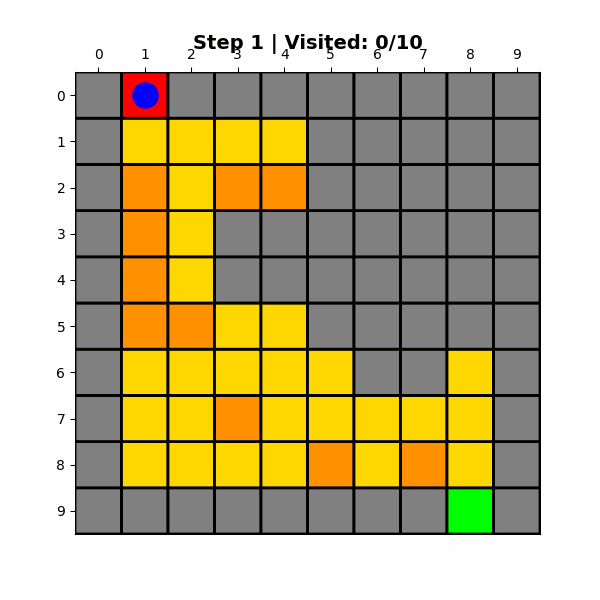

In [10]:
from IPython.display import Image

# Display the GIF
Image(filename='rl_agent_navigation.gif')